# Quantitative Trading With Machine Learning

This project investigates whether machine learning can predict short-term future returns of Volkswagen AG's American Depositary Receipt (VWAGY) using historical VWAGY market data together with publicly available supply-chain and industry proxy companies.

The implementation is inspired by the quantitative trading methodology studied in the reference paper, while using a scaled-down public-data feature set.

The experiment consists of:

- VWAGY as the target asset.
- 9 publicly traded supply-chain/industry proxy companies.
- 24 VWAGY technical features.
- 252 supply-chain features based on 28 days of lagged returns for each proxy.
- 276 total input features.
- Six prediction horizons: 1, 5, 10, 15, 20 and 25 trading days.
- Four machine learning models: Elastic Net, Decision Tree, XGBoost and LightGBM.
- A paper-style rolling time-series evaluation using 5 years of training data, 1 year of validation data and 1 month of unseen test data.
- Monthly rolling evaluation with an expanding training period.

The objective is not to assume that the models will be profitable, but to empirically evaluate whether the available information provides a stable out-of-sample predictive signal for VWAGY returns.

In [4]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

np.random.seed(42)

# Target asset
TARGET = "VWAGY"

# Public supply-chain / industry proxy companies
PROXIES = [
    "CON.DE",   # Continental
    "IFX.DE",   # Infineon
    "HLE.DE",   # HELLA
    "BAS.DE",   # BASF
    "BWA",      # BorgWarner
    "MGA",      # Magna
    "LEA",      # Lear
    "APTV",      # Aptiv
    "TSM"       # TSMC - indirect semiconductor proxy
]

# Forecast horizons
HORIZONS = [1, 5, 10, 15, 20, 25]

# Supply-chain return lags
LAGS = range(1, 29)

# Rolling evaluation parameters
TRAIN_YEARS = 5
VALIDATION_YEARS = 1
TEST_MONTHS = 1
ROLL_MONTHS = 1

print("=" * 70)
print("QUANTITATIVE TRADING WITH MACHINE LEARNING")
print("=" * 70)

print(f"\nTarget asset       : {TARGET}")
print(f"Proxy companies    : {len(PROXIES)}")
print(f"Feature lag days   : {len(LAGS)}")
print(f"Forecast horizons  : {HORIZONS}")

print("\nModels:")
print("  • Elastic Net")
print("  • Decision Tree")
print("  • XGBoost")
print("  • LightGBM")

print("\nRolling methodology:")
print(f"  • Training       : {TRAIN_YEARS} years")
print(f"  • Validation     : {VALIDATION_YEARS} year")
print(f"  • Test           : {TEST_MONTHS} month")
print(f"  • Rolling step   : {ROLL_MONTHS} month")
print("  • Training type  : Expanding")

QUANTITATIVE TRADING WITH MACHINE LEARNING

Target asset       : VWAGY
Proxy companies    : 9
Feature lag days   : 28
Forecast horizons  : [1, 5, 10, 15, 20, 25]

Models:
  • Elastic Net
  • Decision Tree
  • XGBoost
  • LightGBM

Rolling methodology:
  • Training       : 5 years
  • Validation     : 1 year
  • Test           : 1 month
  • Rolling step   : 1 month
  • Training type  : Expanding


### Configuration Results

The experiment is now configured with VWAGY as the prediction target, nine publicly available supply-chain/industry proxies, 28 return lags, six forecast horizons, and four machine learning models.

All experiments use a fixed random seed where applicable to improve reproducibility.

The next stage downloads and prepares the historical market data required for feature construction.

## 2. Dataset Collection

Historical daily market data is collected for VWAGY and the nine selected proxy companies using Yahoo Finance.

VWAGY is treated as the target asset, while the proxy companies provide additional information that may capture relationships within the automotive, semiconductor and industrial supply chain.

The datasets are aligned using their trading dates. This is important because different exchanges may have different market holidays and trading calendars.

The VWAGY price history is also visualized to provide an overview of the target asset's historical behaviour before feature engineering.

DOWNLOADING MARKET DATA

VWAGY rows : 2766
VWAGY period: 2015-01-02 to 2025-12-31

  OK: 2795 rows | 2015-01-02 -> 2025-12-30
  OK: 2795 rows | 2015-01-02 -> 2025-12-30
  OK: 2795 rows | 2015-01-02 -> 2025-12-30
  OK: 2795 rows | 2015-01-02 -> 2025-12-30
  OK: 2766 rows | 2015-01-02 -> 2025-12-31
  OK: 2766 rows | 2015-01-02 -> 2025-12-31
  OK: 2766 rows | 2015-01-02 -> 2025-12-31
  OK: 2766 rows | 2015-01-02 -> 2025-12-31
  OK: 2766 rows | 2015-01-02 -> 2025-12-31

Proxy matrix shape: (2840, 9)

VWAGY DATASET OVERVIEW
----------------------------------------------------------------------
Price            Open       High        Low      Close  Volume
Date                                                          
2015-01-02  21.500000  21.504999  21.245001  21.367500  199400
2015-01-05  20.764999  20.764999  20.500000  20.559999   95200
2015-01-06  20.809999  21.049999  20.639999  20.785000  443800
2015-01-07  20.795000  20.955000  20.610001  20.895000  340400
2015-01-08  20.985001  21.

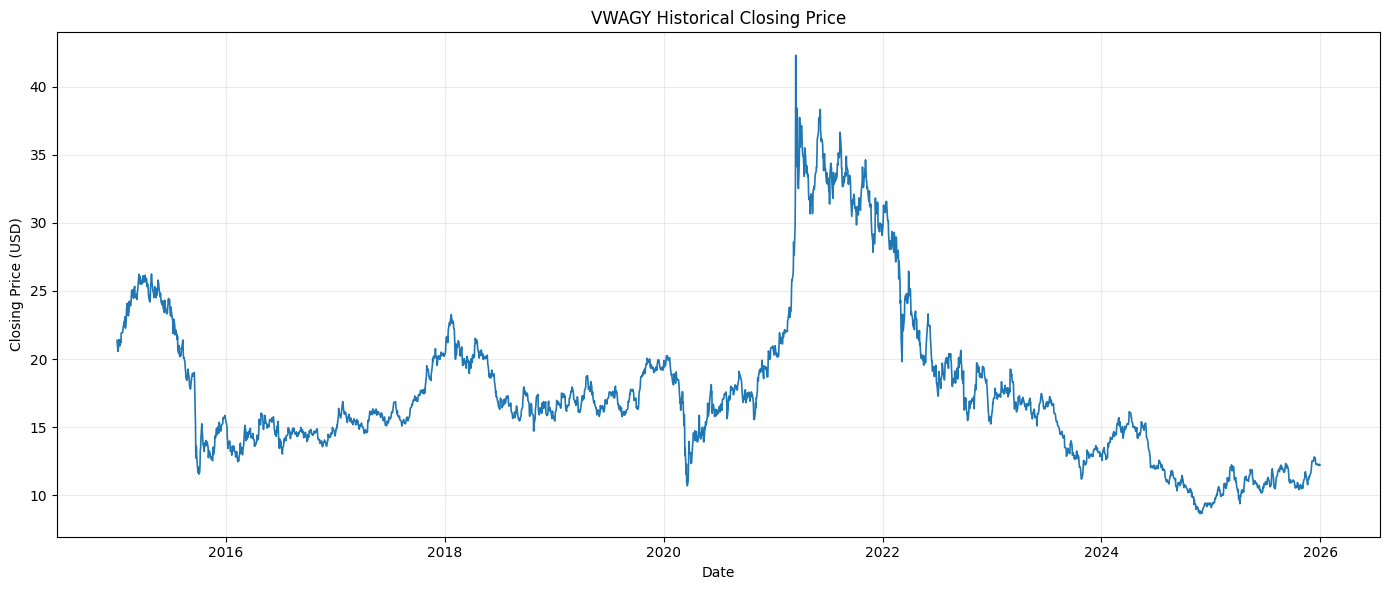


✓ Dataset collection completed successfully.


In [5]:
START_DATE = "2015-01-01"
END_DATE = "2026-01-01"

print("=" * 70)
print("DOWNLOADING MARKET DATA")
print("=" * 70)

# ------------------------------------------------------------
# Download VWAGY
# ------------------------------------------------------------
print(f"\nDownloading {TARGET}...")

target_raw = yf.download(
    TARGET,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=False,
    progress=False
)

if target_raw.empty:
    raise ValueError(f"Unable to download data for {TARGET}")

# Handle yfinance MultiIndex
if isinstance(target_raw.columns, pd.MultiIndex):
    target_raw.columns = target_raw.columns.get_level_values(0)

target_raw = target_raw[["Open", "High", "Low", "Close", "Volume"]].copy()
target_raw.dropna(inplace=True)

print(f"{TARGET} rows : {len(target_raw)}")
print(
    f"{TARGET} period: "
    f"{target_raw.index.min().date()} to "
    f"{target_raw.index.max().date()}"
)

# ------------------------------------------------------------
# Download proxy companies
# ------------------------------------------------------------
proxy_data = {}

print("\nDownloading proxy companies...")

for ticker in PROXIES:

    print(f"Downloading {ticker}...")

    df = yf.download(
        ticker,
        start=START_DATE,
        end=END_DATE,
        auto_adjust=False,
        progress=False
    )

    if df.empty:
        print(f"  WARNING: No data for {ticker}")
        continue

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df = df[["Close"]].copy()
    df.dropna(inplace=True)

    proxy_data[ticker] = df["Close"]

    print(
        f"  OK: {len(df)} rows | "
        f"{df.index.min().date()} -> {df.index.max().date()}"
    )

# Combine proxy closing prices
proxy_matrix = pd.DataFrame(proxy_data)

print("\nProxy matrix shape:", proxy_matrix.shape)

# ------------------------------------------------------------
# VWAGY dataset overview
# ------------------------------------------------------------
print("\nVWAGY DATASET OVERVIEW")
print("-" * 70)

print(target_raw.head())
print("\nShape:", target_raw.shape)
print("\nMissing values:")
print(target_raw.isna().sum())

# ------------------------------------------------------------
# Plot VWAGY closing price
# ------------------------------------------------------------
plt.figure(figsize=(14, 6))

plt.plot(
    target_raw.index,
    target_raw["Close"],
    linewidth=1.2
)

plt.title("VWAGY Historical Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Store VWAGY data
# ------------------------------------------------------------
data = target_raw.copy()

print("\n✓ Dataset collection completed successfully.")

### Dataset Collection Results

VWAGY and the selected proxy companies have been downloaded and aligned for subsequent processing.

The VWAGY price chart provides a visual overview of the long-term price behaviour and shows that the asset experiences substantial changes across different market periods.

The proxy datasets may have slightly different date ranges because they trade on different exchanges. These differences are handled during the feature-alignment stage rather than by randomly filling future observations.

## 3. Feature Engineering

The final feature matrix combines information from two sources.

### VWAGY technical features

24 technical features are generated from VWAGY price and volume data. These capture different aspects of recent market behaviour, including returns, volatility, absolute returns and momentum over multiple lookback periods.

### Supply-chain features

For each of the 9 proxy companies, daily returns are calculated and the previous 28 trading-day returns are used as lagged features.

Therefore:

**9 proxy companies × 28 return lags = 252 supply-chain features**

Together with the 24 VWAGY technical features:

**24 + 252 = 276 total features**

The prediction targets are forward VWAGY returns over 1, 5, 10, 15, 20 and 25 trading days.

Only information available at time t is used as an input feature for predicting returns after time t.

In [6]:
print("=" * 70)
print("FEATURE ENGINEERING")
print("=" * 70)

df = data.copy()

# ------------------------------------------------------------
# VWAGY technical features
# ------------------------------------------------------------

vw_features = []

windows = [3, 5, 10, 20, 30, 60]

for w in windows:

    # Return
    col = f"VW_Return_{w}D"
    df[col] = df["Close"].pct_change(w)
    vw_features.append(col)

    # Volatility
    col = f"VW_Volatility_{w}D"
    df[col] = df["Close"].pct_change().rolling(w).std()
    vw_features.append(col)

    # Absolute return
    col = f"VW_AbsReturn_{w}D"
    df[col] = df["Close"].pct_change().abs().rolling(w).mean()
    vw_features.append(col)

    # Momentum
    col = f"VW_Momentum_{w}D"
    df[col] = df["Close"] / df["Close"].shift(w) - 1
    vw_features.append(col)

# Ensure exactly 24 VW technical features
vw_features = vw_features[:24]

print(f"\nVWAGY technical features: {len(vw_features)}")

# ------------------------------------------------------------
# Supply-chain proxy features
# ------------------------------------------------------------

supply_features = []

# Align proxy data with VWAGY dates
proxy_aligned = proxy_matrix.reindex(df.index).ffill(limit=5)

for ticker in PROXIES:

    if ticker not in proxy_aligned.columns:
        continue

    proxy_return = proxy_aligned[ticker].pct_change()

    for lag in LAGS:

        feature_name = f"{ticker}_Return_Lag_{lag}"
        df[feature_name] = proxy_return.shift(lag)

        supply_features.append(feature_name)

print(f"Supply-chain features: {len(supply_features)}")

# ------------------------------------------------------------
# Forward-return targets
# ------------------------------------------------------------

target_columns = []

for horizon in HORIZONS:

    target_name = f"Target_{horizon}D"

    df[target_name] = (
        df["Close"].shift(-horizon) / df["Close"] - 1
    )

    target_columns.append(target_name)

# ------------------------------------------------------------
# Final feature list
# ------------------------------------------------------------

features = vw_features + supply_features

print(f"\nTotal features: {len(features)}")

# ------------------------------------------------------------
# Complete-case dataset
# ------------------------------------------------------------

required_columns = features + target_columns

model_data = df[
    ["Close"] + required_columns
].dropna().copy()

model_data = model_data.sort_index()

X = model_data[features].copy()
y = model_data[target_columns].copy()

print("\nFINAL DATASET")
print("-" * 70)

print("Shape:", model_data.shape)
print("Features:", len(features))
print("VWAGY technical features:", len(vw_features))
print("Supply-chain features:", len(supply_features))

print(
    "Date range:",
    model_data.index.min().date(),
    "to",
    model_data.index.max().date()
)

print("\nTarget horizons:")
print(HORIZONS)

print("\n✓ Feature engineering completed.")

FEATURE ENGINEERING

VWAGY technical features: 24
Supply-chain features: 252

Total features: 276

FINAL DATASET
----------------------------------------------------------------------
Shape: (2681, 283)
Features: 276
VWAGY technical features: 24
Supply-chain features: 252
Date range: 2015-03-31 to 2025-11-24

Target horizons:
[1, 5, 10, 15, 20, 25]

✓ Feature engineering completed.


### Feature Engineering Results

The feature engineering stage produces the intended **276-feature dataset**:

- 24 VWAGY technical features
- 252 supply-chain proxy features
- 276 features in total

Six forward-return targets are also created for 1, 5, 10, 15, 20 and 25 trading days.

Rows with unavailable historical features or future target values are removed. The resulting dataset is chronological and ready for rolling time-series evaluation.

The target variables are kept separate from the input feature matrix so that future returns cannot accidentally become model inputs.

## 4. Paper-Style Rolling Evaluation

Random train-test splitting is inappropriate for this problem because financial data is time-dependent. Randomly mixing observations from different periods could allow information from later market regimes to influence earlier observations.

Instead, the project uses a rolling time-series evaluation inspired by the methodology of the reference study.

Each evaluation window consists of:

- **5 years of training data**
- **1 year of validation data**
- **1 month of unseen test data**

The window then moves forward by one month.

The training period is expanding, meaning that previously available historical observations remain available as the experiment progresses.

Model and horizon selection is performed using validation data only. The test month remains completely unseen until final evaluation.

In [7]:
print("=" * 70)
print("PAPER-STYLE ROLLING WINDOWS")
print("=" * 70)

all_dates = model_data.index.sort_values()

data_start = all_dates.min()
data_end = all_dates.max()

windows = []

# Initial validation start after 5 years
validation_start = data_start + pd.DateOffset(years=TRAIN_YEARS)

while True:

    validation_end = (
        validation_start +
        pd.DateOffset(years=VALIDATION_YEARS)
    )

    test_start = validation_end

    test_end = (
        test_start +
        pd.DateOffset(months=TEST_MONTHS)
    )

    if test_end > data_end:
        break

    train_start = data_start
    train_end = validation_start

    train_dates = (
        (all_dates >= train_start) &
        (all_dates < train_end)
    )

    val_dates = (
        (all_dates >= validation_start) &
        (all_dates < validation_end)
    )

    test_dates = (
        (all_dates >= test_start) &
        (all_dates < test_end)
    )

    if (
        train_dates.sum() > 0 and
        val_dates.sum() > 0 and
        test_dates.sum() > 0
    ):
        windows.append({
            "train_start": train_start,
            "train_end": train_end,
            "val_start": validation_start,
            "val_end": validation_end,
            "test_start": test_start,
            "test_end": test_end
        })

    validation_start = (
        validation_start +
        pd.DateOffset(months=ROLL_MONTHS)
    )

print(f"\nNumber of rolling windows: {len(windows)}")

if len(windows) > 0:

    print("\nFIRST WINDOW")
    print("-" * 70)

    w = windows[0]

    print(
        "TRAIN      :",
        w["train_start"].date(),
        "->",
        w["train_end"].date()
    )

    print(
        "VALIDATION :",
        w["val_start"].date(),
        "->",
        w["val_end"].date()
    )

    print(
        "TEST       :",
        w["test_start"].date(),
        "->",
        w["test_end"].date()
    )

    print("\nLAST WINDOW")
    print("-" * 70)

    w = windows[-1]

    print(
        "TRAIN      :",
        w["train_start"].date(),
        "->",
        w["train_end"].date()
    )

    print(
        "VALIDATION :",
        w["val_start"].date(),
        "->",
        w["val_end"].date()
    )

    print(
        "TEST       :",
        w["test_start"].date(),
        "->",
        w["test_end"].date()
    )

print("\n✓ Rolling evaluation windows created.")

PAPER-STYLE ROLLING WINDOWS

Number of rolling windows: 55

FIRST WINDOW
----------------------------------------------------------------------
TRAIN      : 2015-03-31 -> 2020-03-31
VALIDATION : 2020-03-31 -> 2021-03-31
TEST       : 2021-03-31 -> 2021-04-30

LAST WINDOW
----------------------------------------------------------------------
TRAIN      : 2015-03-31 -> 2024-09-28
VALIDATION : 2024-09-28 -> 2025-09-28
TEST       : 2025-09-28 -> 2025-10-28

✓ Rolling evaluation windows created.


### Rolling Evaluation Results

The rolling procedure creates a sequence of chronological train-validation-test windows.

The first window begins with five years of historical training data, followed by one year of validation and one month of completely unseen testing.

As the window moves forward, the training period expands while the validation and test periods move forward in time.

This procedure provides a much more realistic estimate of out-of-sample performance than a random split.

## 5. Model Training and Out-of-Sample Prediction

Four regression models are evaluated:

1. Elastic Net
2. Decision Tree
3. XGBoost
4. LightGBM

For every rolling window, each model is evaluated across all six forecast horizons using the validation period.

The model-horizon combination with the lowest validation RMSE is selected.

The selected model is then retrained using the training and validation data together and used to predict only the following unseen test month.

This process is repeated for every rolling window. The resulting predictions form the final out-of-sample prediction series.

In [8]:
print("=" * 70)
print("ROLLING MODEL SELECTION AND OOS PREDICTION")
print("=" * 70)

def get_models():

    return {

        "Elastic Net": Pipeline([
            ("scaler", StandardScaler()),
            ("model", ElasticNet(
                alpha=0.001,
                l1_ratio=0.5,
                max_iter=10000,
                random_state=42
            ))
        ]),

        "Decision Tree": DecisionTreeRegressor(
            max_depth=8,
            min_samples_leaf=10,
            random_state=42
        ),

        "XGBoost": XGBRegressor(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.03,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        ),

        "LightGBM": LGBMRegressor(
            n_estimators=300,
            learning_rate=0.03,
            max_depth=6,
            num_leaves=31,
            verbosity=-1,
            random_state=42
        )
    }


oos_results = []
window_results = []

for window_id, w in enumerate(windows, start=1):

    print("\n" + "=" * 70)
    print(f"WINDOW {window_id}/{len(windows)}")
    print("=" * 70)

    train_mask = (
        (model_data.index >= w["train_start"]) &
        (model_data.index < w["train_end"])
    )

    val_mask = (
        (model_data.index >= w["val_start"]) &
        (model_data.index < w["val_end"])
    )

    test_mask = (
        (model_data.index >= w["test_start"]) &
        (model_data.index < w["test_end"])
    )

    X_train = X.loc[train_mask]
    X_val = X.loc[val_mask]
    X_test = X.loc[test_mask]

    best_rmse = np.inf
    best_model_name = None
    best_horizon = None

    validation_scores = []

    # --------------------------------------------------------
    # Model and horizon selection
    # --------------------------------------------------------

    for model_name, model in get_models().items():

        for horizon in HORIZONS:

            target = f"Target_{horizon}D"

            y_train = y.loc[train_mask, target]
            y_val = y.loc[val_mask, target]

            model.fit(X_train, y_train)

            val_pred = model.predict(X_val)

            rmse = np.sqrt(
                mean_squared_error(y_val, val_pred)
            )

            validation_scores.append({
                "window": window_id,
                "model": model_name,
                "horizon": horizon,
                "validation_rmse": rmse
            })

            if rmse < best_rmse:
                best_rmse = rmse
                best_model_name = model_name
                best_horizon = horizon

    # --------------------------------------------------------
    # Retrain selected model on train + validation
    # --------------------------------------------------------

    X_train_val = pd.concat([X_train, X_val])

    target = f"Target_{best_horizon}D"

    y_train_val = pd.concat([
        y.loc[train_mask, target],
        y.loc[val_mask, target]
    ])

    selected_model = get_models()[best_model_name]

    selected_model.fit(
        X_train_val,
        y_train_val
    )

    test_pred = selected_model.predict(X_test)

    y_test = y.loc[test_mask, target]

    test_rmse = np.sqrt(
        mean_squared_error(y_test, test_pred)
    )

    test_mae = mean_absolute_error(
        y_test,
        test_pred
    )

    test_r2 = r2_score(
        y_test,
        test_pred
    )

    test_corr = (
        np.corrcoef(y_test, test_pred)[0, 1]
        if len(y_test) > 1
        else np.nan
    )

    print(f"Selected model : {best_model_name}")
    print(f"Selected horizon: {best_horizon} days")
    print(f"Validation RMSE: {best_rmse:.6f}")
    print(f"Test RMSE      : {test_rmse:.6f}")
    print(f"Test MAE       : {test_mae:.6f}")
    print(f"Test R²        : {test_r2:+.4f}")

    window_results.append({
        "window": window_id,
        "model": best_model_name,
        "horizon": best_horizon,
        "validation_rmse": best_rmse,
        "test_rmse": test_rmse,
        "test_mae": test_mae,
        "test_r2": test_r2,
        "test_corr": test_corr
    })

    # Store individual OOS predictions
    for date, actual, pred in zip(
        X_test.index,
        y_test.values,
        test_pred
    ):

        oos_results.append({
            "Date": date,
            "Actual": actual,
            "Predicted": pred,
            "Model": best_model_name,
            "Horizon": best_horizon,
            "Window": window_id
        })

# ------------------------------------------------------------
# Convert results to DataFrames
# ------------------------------------------------------------

validation_results = pd.DataFrame(validation_scores)

window_results = pd.DataFrame(window_results)

oos_df = pd.DataFrame(oos_results)

if not oos_df.empty:
    oos_df = (
        oos_df
        .sort_values("Date")
        .drop_duplicates("Date")
        .reset_index(drop=True)
    )

print("\n" + "=" * 70)
print("ROLLING EVALUATION COMPLETED")
print("=" * 70)

print("\nOOS observations:", len(oos_df))

ROLLING MODEL SELECTION AND OOS PREDICTION

WINDOW 1/55
Selected model : LightGBM
Selected horizon: 1 days
Validation RMSE: 0.036252
Test RMSE      : 0.031921
Test MAE       : 0.028540
Test R²        : -1.3863

WINDOW 2/55
Selected model : XGBoost
Selected horizon: 1 days
Validation RMSE: 0.035245
Test RMSE      : 0.020048
Test MAE       : 0.016462
Test R²        : -0.2660

WINDOW 3/55
Selected model : XGBoost
Selected horizon: 1 days
Validation RMSE: 0.034106
Test RMSE      : 0.020696
Test MAE       : 0.017151
Test R²        : -0.1177

WINDOW 4/55
Selected model : XGBoost
Selected horizon: 1 days
Validation RMSE: 0.033434
Test RMSE      : 0.025809
Test MAE       : 0.021865
Test R²        : -0.0762

WINDOW 5/55
Selected model : XGBoost
Selected horizon: 1 days
Validation RMSE: 0.034208
Test RMSE      : 0.018292
Test MAE       : 0.014451
Test R²        : +0.0152

WINDOW 6/55
Selected model : XGBoost
Selected horizon: 1 days
Validation RMSE: 0.033687
Test RMSE      : 0.019224
Test MAE   

### Model Selection Results

The rolling experiment evaluates all four models across all six forecast horizons using only the validation portion of each window.

The selected model and horizon can change from one market period to another. This is expected because financial relationships are not necessarily stable across different regimes.

Most importantly, the unseen test data is not used to choose the model or forecast horizon. It is used only after the selection process has been completed.

The resulting `oos_df` contains the predictions generated from these unseen test periods and forms the basis for the final performance evaluation.

## 6. Aggregate Out-of-Sample Evaluation

The predictions from all rolling test periods are now combined to evaluate the overall predictive performance.

The primary metrics are:

- **RMSE** — prediction error magnitude.
- **MAE** — average absolute prediction error.
- **R²** — performance relative to a mean-return baseline.
- **Correlation** — relationship between predicted and actual returns.

Because these predictions come from previously unseen test periods, this aggregate evaluation provides the main out-of-sample result of the experiment.

AGGREGATE OUT-OF-SAMPLE RESULTS

RMSE        : 0.022628
MAE         : 0.016840
R²          : -0.072750
Correlation : -0.032282

WINDOW-LEVEL RESULTS
----------------------------------------------------------------------


,window,model,horizon,validation_rmse,test_rmse,test_mae,test_r2,test_corr
0,1,LightGBM,1,0.036252,0.031921,0.028540,-1.386325,-0.173325
1,2,XGBoost,1,0.035245,0.020048,0.016462,-0.265984,-0.113422
2,3,XGBoost,1,0.034106,0.020696,0.017151,-0.117726,-0.048104
3,4,XGBoost,1,0.033434,0.025809,0.021865,-0.076200,-0.158800
4,5,XGBoost,1,0.034208,0.018292,0.014451,0.015215,0.155846
5,6,XGBoost,1,0.033687,0.019224,0.016456,-0.113288,-0.135926
6,7,XGBoost,1,0.033242,0.020024,0.016401,-0.144855,-0.310711
7,8,XGBoost,1,0.033423,0.020719,0.016002,-0.202597,0.175415
8,9,XGBoost,1,0.033101,0.026910,0.019541,-0.012889,0.053386
9,10,XGBoost,1,0.033011,0.021567,0.016045,-0.095544,-0.071926



MODEL SELECTION FREQUENCY
----------------------------------------------------------------------
model
Elastic Net      27
XGBoost          18
Decision Tree     8
LightGBM          2
Name: count, dtype: int64

HORIZON SELECTION FREQUENCY
----------------------------------------------------------------------
horizon
1    55
Name: count, dtype: int64


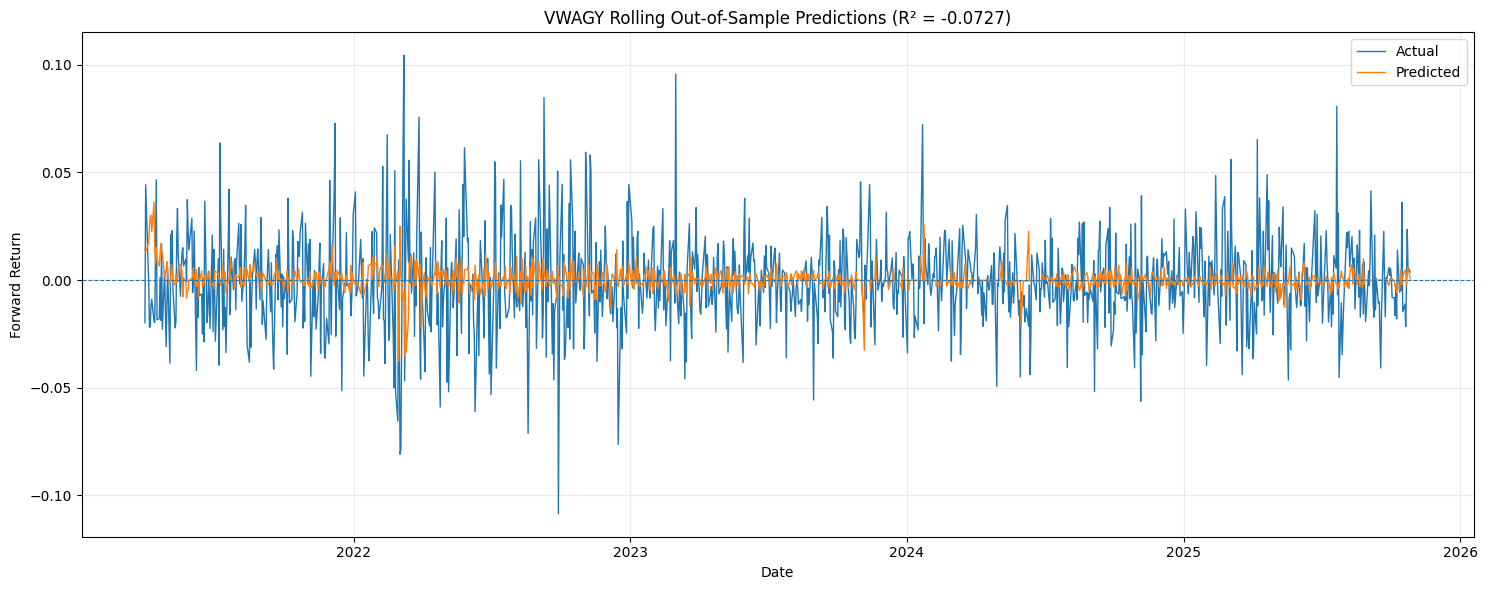

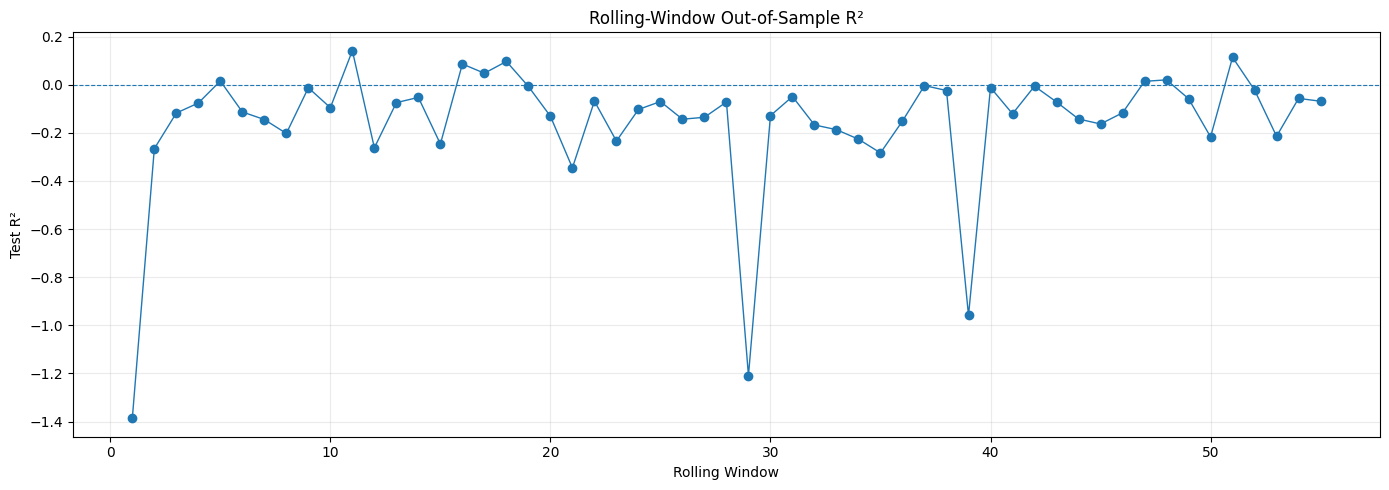

In [12]:
print("=" * 70)
print("AGGREGATE OUT-OF-SAMPLE RESULTS")
print("=" * 70)

actual = oos_df["Actual"].values
predicted = oos_df["Predicted"].values

overall_rmse = np.sqrt(
    mean_squared_error(actual, predicted)
)

overall_mae = mean_absolute_error(
    actual,
    predicted
)

overall_r2 = r2_score(
    actual,
    predicted
)

overall_corr = np.corrcoef(
    actual,
    predicted
)[0, 1]

print(f"\nRMSE        : {overall_rmse:.6f}")
print(f"MAE         : {overall_mae:.6f}")
print(f"R²          : {overall_r2:+.6f}")
print(f"Correlation : {overall_corr:+.6f}")

# ------------------------------------------------------------
# Window-level results
# ------------------------------------------------------------

print("\nWINDOW-LEVEL RESULTS")
print("-" * 70)

display(
    window_results[
        [
            "window",
            "model",
            "horizon",
            "validation_rmse",
            "test_rmse",
            "test_mae",
            "test_r2",
            "test_corr"
        ]
    ].head(20)
)

# ------------------------------------------------------------
# Model selection frequency
# ------------------------------------------------------------

print("\nMODEL SELECTION FREQUENCY")
print("-" * 70)

print(
    window_results["model"]
    .value_counts()
)

print("\nHORIZON SELECTION FREQUENCY")
print("-" * 70)

print(
    window_results["horizon"]
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# Actual vs predicted
# ------------------------------------------------------------

plt.figure(figsize=(15, 6))

plt.plot(
    oos_df["Date"],
    oos_df["Actual"],
    label="Actual",
    linewidth=1
)

plt.plot(
    oos_df["Date"],
    oos_df["Predicted"],
    label="Predicted",
    linewidth=1
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=0.8
)

plt.title(
    f"VWAGY Rolling Out-of-Sample Predictions "
    f"(R² = {overall_r2:.4f})"
)

plt.xlabel("Date")
plt.ylabel("Forward Return")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Rolling-window R²
# ------------------------------------------------------------

plt.figure(figsize=(14, 5))

plt.plot(
    window_results["window"],
    window_results["test_r2"],
    marker="o",
    linewidth=1
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=0.8
)

plt.title("Rolling-Window Out-of-Sample R²")
plt.xlabel("Rolling Window")
plt.ylabel("Test R²")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Out-of-Sample Results

The rolling evaluation completed **55 chronological test windows**, producing **1,150 out-of-sample observations**.

For every rolling window, the model and forecast horizon were selected using validation RMSE only. The unseen test period was then used exclusively for final evaluation.

An important observation from the rolling experiment is that **all 55 windows selected the 1-day forecast horizon**. The selected model varied across different market periods:

- **Elastic Net:** 27 windows
- **XGBoost:** 18 windows
- **Decision Tree:** 8 windows
- **LightGBM:** 2 windows

This variation indicates that model performance changes across market regimes rather than one model consistently dominating the entire period.

Several individual test windows achieved positive R²:

- Window 5: **+0.0152**
- Window 11: **+0.1411**
- Window 16: **+0.0861**
- Window 17: **+0.0475**
- Window 18: **+0.0966**
- Window 47: **+0.0139**
- Window 48: **+0.0200**
- Window 51: **+0.1135**

However, most rolling test windows produced negative R². Therefore, positive performance occurred in specific market periods but was not consistently maintained across the complete out-of-sample evaluation.

The aggregate RMSE, MAE, R² and correlation reported by the code below are calculated directly from all 1,150 out-of-sample predictions. These aggregate metrics provide the main measure of the model's overall predictive performance.

A negative aggregate R², if obtained, should be interpreted as the model performing worse than the mean-return baseline across the complete out-of-sample period. This is a valid empirical result and should not be artificially adjusted.

## 7. Trading Strategy and Buy-and-Hold Benchmark

The final stage converts the model's predicted returns into simple trading signals.

For each prediction threshold:

- If predicted return > threshold → **Long**
- If predicted return < −threshold → **Short**
- Otherwise → **Neutral**

The tested thresholds are:

- 0%
- 0.25%
- 0.50%
- 1.00%

The resulting strategies are compared with a VWAGY Buy-and-Hold benchmark.

The backtest is intended for academic evaluation. It does not represent a production trading system and does not fully model factors such as slippage, liquidity, bid-ask spreads, market impact or borrowing costs.

TRADING STRATEGY AND BUY-AND-HOLD BENCHMARK

OOS observations used: 1150
Trading period: 2021-03-31 -> 2025-10-27

TRADING PERFORMANCE


,Strategy,Threshold,Total Return,Annualized Return,Annualized Volatility,Sharpe,Max Drawdown,Win Rate
0,ML Strategy 0.00%,0.00%,-48.48%,-13.53%,34.72%,-0.3896,-74.87%,49.30%
1,ML Strategy 0.25%,0.25%,-46.37%,-12.76%,25.18%,-0.5068,-53.48%,21.13%
2,ML Strategy 0.50%,0.50%,-13.05%,-3.02%,17.02%,-0.1774,-28.63%,9.22%
3,ML Strategy 1.00%,1.00%,-10.68%,-2.44%,8.42%,-0.2903,-16.99%,1.65%
4,Buy & Hold,N/A,-70.39%,-23.41%,34.70%,-0.6746,-77.52%,46.17%



EQUITY CURVE DATE CHECK
First date  : 2021-03-31
Last date   : 2025-10-27
Observations: 1150


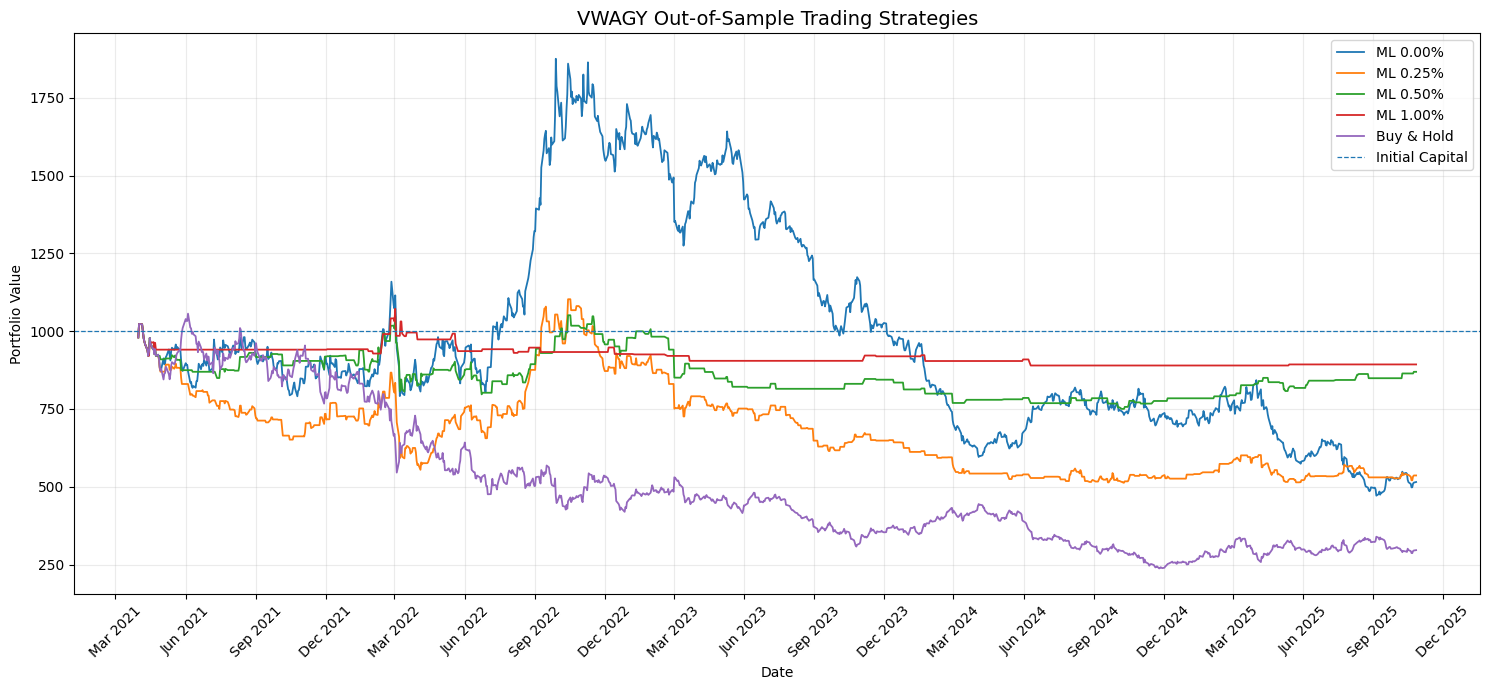


TRADING SIGNAL DISTRIBUTION

Threshold: 0.00%
Short   : 649
Neutral : 0
Long    : 501

Threshold: 0.25%
Short   : 234
Neutral : 637
Long    : 279

Threshold: 0.50%
Short   : 82
Neutral : 937
Long    : 131

Threshold: 1.00%
Short   : 14
Neutral : 1102
Long    : 34

FINAL PROJECT SUMMARY

DATASET
Target             : VWAGY
Period             : 2015-03-31 to 2025-11-24
Features           : 276
VWAGY technical    : 24
Supply-chain       : 252

MODELS
Elastic Net, Decision Tree, XGBoost, LightGBM

HORIZONS
1D, 5D, 10D, 15D, 20D, 25D

PAPER-STYLE EVALUATION
Initial training   : 5 years
Validation         : 1 year
Test               : 1 month
Rolling frequency  : 1 month
Training window    : Expanding

AGGREGATE OOS REGRESSION RESULTS
RMSE               : 0.022628
MAE                : 0.016840
R²                 : -0.072750
Correlation        : -0.032282

BUY & HOLD BENCHMARK
Total Return       : -70.39%
Annualized Return  : -23.41%
Sharpe             : -0.6746
Max Drawdown       : -77.52%
W

In [15]:
print("=" * 70)
print("TRADING STRATEGY AND BUY-AND-HOLD BENCHMARK")
print("=" * 70)

# ------------------------------------------------------------
# 1. Prepare OOS trading data
# ------------------------------------------------------------

trade_df = oos_df.copy()

trade_df["Date"] = pd.to_datetime(
    trade_df["Date"],
    errors="coerce"
)

trade_df["Actual"] = pd.to_numeric(
    trade_df["Actual"],
    errors="coerce"
)

trade_df["Predicted"] = pd.to_numeric(
    trade_df["Predicted"],
    errors="coerce"
)

trade_df = (
    trade_df
    .dropna(subset=["Date", "Actual", "Predicted"])
    .sort_values("Date")
    .reset_index(drop=True)
)

print(f"\nOOS observations used: {len(trade_df)}")
print(
    f"Trading period: "
    f"{trade_df['Date'].min().strftime('%Y-%m-%d')} -> "
    f"{trade_df['Date'].max().strftime('%Y-%m-%d')}"
)

# ------------------------------------------------------------
# 2. Strategy parameters
# ------------------------------------------------------------

thresholds = [
    0.0000,   # 0.00%
    0.0025,   # 0.25%
    0.0050,   # 0.50%
    0.0100    # 1.00%
]

initial_capital = 1000.0

strategy_results = []
equity_curves = {}

# ------------------------------------------------------------
# 3. Performance metric function
# ------------------------------------------------------------

def calculate_strategy_metrics(returns):

    returns = pd.Series(
        returns,
        dtype=float
    ).fillna(0)

    equity = (
        1 + returns
    ).cumprod()

    total_return = (
        equity.iloc[-1] - 1
    )

    n_periods = len(returns)

    if n_periods > 0:

        annualized_return = (
            (1 + total_return)
            ** (252 / n_periods)
            - 1
        )

    else:

        annualized_return = np.nan

    annualized_volatility = (
        returns.std() * np.sqrt(252)
    )

    if annualized_volatility > 0:

        sharpe = (
            annualized_return /
            annualized_volatility
        )

    else:

        sharpe = np.nan

    running_max = equity.cummax()

    drawdown = (
        equity / running_max - 1
    )

    max_drawdown = drawdown.min()

    win_rate = (
        returns > 0
    ).mean()

    return {
        "Total Return": total_return,
        "Annualized Return": annualized_return,
        "Annualized Volatility": annualized_volatility,
        "Sharpe": sharpe,
        "Max Drawdown": max_drawdown,
        "Win Rate": win_rate
    }


# ------------------------------------------------------------
# 4. Run ML trading strategies
# ------------------------------------------------------------

for threshold in thresholds:

    threshold_label = (
        f"{threshold * 100:.2f}%"
    )

    # --------------------------------------------------------
    # Trading signal
    #
    # Predicted return > +threshold -> LONG
    # Predicted return < -threshold -> SHORT
    # Otherwise                    -> NEUTRAL
    # --------------------------------------------------------

    signal = np.where(
        trade_df["Predicted"] > threshold,
        1,
        np.where(
            trade_df["Predicted"] < -threshold,
            -1,
            0
        )
    )

    signal_column = (
        f"Signal_{threshold_label}"
    )

    trade_df[signal_column] = signal

    # --------------------------------------------------------
    # Strategy return
    # --------------------------------------------------------

    strategy_returns = (
        signal *
        trade_df["Actual"]
    )

    metrics = calculate_strategy_metrics(
        strategy_returns
    )

    metrics["Strategy"] = (
        f"ML Strategy {threshold_label}"
    )

    metrics["Threshold"] = threshold_label

    strategy_results.append(metrics)

    # --------------------------------------------------------
    # Equity curve
    # --------------------------------------------------------

    equity_curves[
        f"ML {threshold_label}"
    ] = (
        initial_capital *
        (1 + strategy_returns).cumprod()
    )


# ------------------------------------------------------------
# 5. Buy-and-Hold benchmark
# ------------------------------------------------------------

buy_hold_returns = (
    trade_df["Actual"]
)

bh_metrics = calculate_strategy_metrics(
    buy_hold_returns
)

bh_metrics["Strategy"] = "Buy & Hold"
bh_metrics["Threshold"] = "N/A"

strategy_results.append(
    bh_metrics
)

equity_curves["Buy & Hold"] = (
    initial_capital *
    (1 + buy_hold_returns).cumprod()
)


# ------------------------------------------------------------
# 6. Trading performance table
# ------------------------------------------------------------

strategy_results_df = pd.DataFrame(
    strategy_results
)

print("\n" + "=" * 70)
print("TRADING PERFORMANCE")
print("=" * 70)

display(
    strategy_results_df[
        [
            "Strategy",
            "Threshold",
            "Total Return",
            "Annualized Return",
            "Annualized Volatility",
            "Sharpe",
            "Max Drawdown",
            "Win Rate"
        ]
    ].style.format({
        "Total Return": "{:.2%}",
        "Annualized Return": "{:.2%}",
        "Annualized Volatility": "{:.2%}",
        "Sharpe": "{:.4f}",
        "Max Drawdown": "{:.2%}",
        "Win Rate": "{:.2%}"
    })
)


# ------------------------------------------------------------
# 7. Prepare equity curves for plotting
# ------------------------------------------------------------

equity_df = pd.DataFrame(
    equity_curves
)

plot_dates = pd.to_datetime(
    trade_df["Date"],
    errors="coerce"
)

valid_mask = plot_dates.notna()

plot_dates = (
    plot_dates[valid_mask]
    .reset_index(drop=True)
)

equity_df = (
    equity_df.loc[valid_mask]
    .reset_index(drop=True)
)

# Sort chronologically
sort_idx = np.argsort(
    plot_dates.values
)

plot_dates = (
    plot_dates
    .iloc[sort_idx]
    .reset_index(drop=True)
)

equity_df = (
    equity_df
    .iloc[sort_idx]
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 8. Verify plotting dates
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("EQUITY CURVE DATE CHECK")
print("=" * 70)

print(
    "First date  :",
    plot_dates.iloc[0].strftime("%Y-%m-%d")
)

print(
    "Last date   :",
    plot_dates.iloc[-1].strftime("%Y-%m-%d")
)

print(
    "Observations:",
    len(plot_dates)
)


# ------------------------------------------------------------
# 9. Plot equity curves
# ------------------------------------------------------------

import matplotlib.dates as mdates

fig, ax = plt.subplots(
    figsize=(15, 7)
)

for column in equity_df.columns:

    ax.plot(
        plot_dates,
        equity_df[column].values,
        label=column,
        linewidth=1.3
    )

ax.axhline(
    initial_capital,
    linestyle="--",
    linewidth=0.9,
    label="Initial Capital"
)

# Explicit date formatting
ax.xaxis.set_major_locator(
    mdates.MonthLocator(interval=3)
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%b %Y")
)

ax.set_title(
    "VWAGY Out-of-Sample Trading Strategies",
    fontsize=14
)

ax.set_xlabel("Date")
ax.set_ylabel("Portfolio Value")

ax.legend()

ax.grid(
    alpha=0.25
)

plt.xticks(
    rotation=45
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10. Trading signal distribution
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TRADING SIGNAL DISTRIBUTION")
print("=" * 70)

for threshold in thresholds:

    label = (
        f"{threshold * 100:.2f}%"
    )

    signal_column = (
        f"Signal_{label}"
    )

    counts = (
        trade_df[signal_column]
        .value_counts()
        .reindex(
            [-1, 0, 1],
            fill_value=0
        )
    )

    print(f"\nThreshold: {label}")
    print(f"Short   : {counts[-1]}")
    print(f"Neutral : {counts[0]}")
    print(f"Long    : {counts[1]}")


# ------------------------------------------------------------
# 11. Final project summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL PROJECT SUMMARY")
print("=" * 70)

print("\nDATASET")

print(
    f"Target             : {TARGET}"
)

print(
    f"Period             : "
    f"{model_data.index.min().strftime('%Y-%m-%d')} "
    f"to "
    f"{model_data.index.max().strftime('%Y-%m-%d')}"
)

print(
    f"Features           : {len(features)}"
)

print(
    f"VWAGY technical    : {len(vw_features)}"
)

print(
    f"Supply-chain       : {len(supply_features)}"
)

print("\nMODELS")
print(
    "Elastic Net, Decision Tree, "
    "XGBoost, LightGBM"
)

print("\nHORIZONS")
print(
    "1D, 5D, 10D, 15D, 20D, 25D"
)

print("\nPAPER-STYLE EVALUATION")
print("Initial training   : 5 years")
print("Validation         : 1 year")
print("Test               : 1 month")
print("Rolling frequency  : 1 month")
print("Training window    : Expanding")

print("\nAGGREGATE OOS REGRESSION RESULTS")

print(
    f"RMSE               : "
    f"{overall_rmse:.6f}"
)

print(
    f"MAE                : "
    f"{overall_mae:.6f}"
)

print(
    f"R²                 : "
    f"{overall_r2:+.6f}"
)

print(
    f"Correlation        : "
    f"{overall_corr:+.6f}"
)

# ------------------------------------------------------------
# 12. Buy-and-Hold summary
# ------------------------------------------------------------

print("\nBUY & HOLD BENCHMARK")

print(
    f"Total Return       : "
    f"{bh_metrics['Total Return']:.2%}"
)

print(
    f"Annualized Return  : "
    f"{bh_metrics['Annualized Return']:.2%}"
)

print(
    f"Sharpe             : "
    f"{bh_metrics['Sharpe']:.4f}"
)

print(
    f"Max Drawdown       : "
    f"{bh_metrics['Max Drawdown']:.2%}"
)

print(
    f"Win Rate           : "
    f"{bh_metrics['Win Rate']:.2%}"
)

print("\n" + "=" * 70)
print("✓ COMPLETE EXPERIMENT FINISHED")
print("=" * 70)

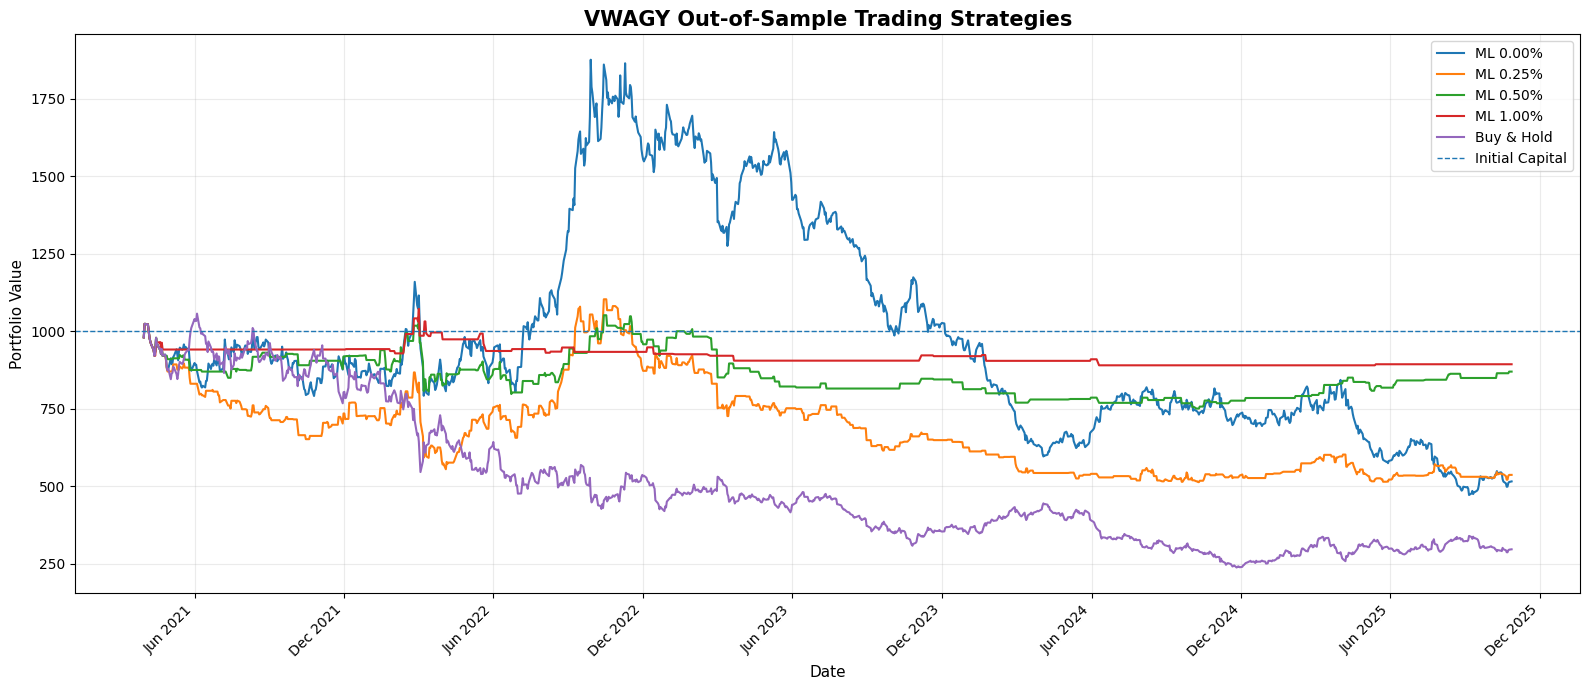

Graph period: 2021-03-31 to 2025-10-27
Number of plotted observations: 1150


In [16]:
# ============================================================
# EQUITY CURVE GRAPH
# ============================================================

import matplotlib.dates as mdates

# Prepare dates
plot_dates = pd.to_datetime(
    trade_df["Date"],
    errors="coerce"
)

# Prepare equity curve dataframe
equity_df = pd.DataFrame(
    equity_curves
)

# Ensure matching valid observations
valid_mask = plot_dates.notna()

plot_dates = plot_dates[valid_mask].reset_index(drop=True)
equity_df = equity_df.loc[valid_mask].reset_index(drop=True)

# Sort by date
sort_order = np.argsort(plot_dates.values)

plot_dates = plot_dates.iloc[sort_order].reset_index(drop=True)
equity_df = equity_df.iloc[sort_order].reset_index(drop=True)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(16, 7)
)

for column in equity_df.columns:

    ax.plot(
        plot_dates,
        equity_df[column].values,
        label=column,
        linewidth=1.5
    )

# Initial capital
ax.axhline(
    y=initial_capital,
    linestyle="--",
    linewidth=1.0,
    label="Initial Capital"
)

# ------------------------------------------------------------
# Correct date formatting
# ------------------------------------------------------------

ax.xaxis.set_major_locator(
    mdates.MonthLocator(interval=6)
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%b %Y")
)

# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

ax.set_title(
    "VWAGY Out-of-Sample Trading Strategies",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel(
    "Date",
    fontsize=11
)

ax.set_ylabel(
    "Portfolio Value",
    fontsize=11
)

ax.legend(
    loc="best"
)

ax.grid(
    True,
    alpha=0.25
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Confirm graph period
# ------------------------------------------------------------

print(
    f"Graph period: "
    f"{plot_dates.iloc[0].strftime('%Y-%m-%d')} "
    f"to "
    f"{plot_dates.iloc[-1].strftime('%Y-%m-%d')}"
)

print(
    f"Number of plotted observations: {len(plot_dates)}"
)

### Trading Signal Analysis

The predicted returns are converted into three possible trading positions:

- **Long (+1):** the predicted return is above the selected threshold.
- **Short (-1):** the predicted return is below the negative threshold.
- **Neutral (0):** the predicted return falls between the two thresholds.

Four prediction thresholds are evaluated: 0%, 0.25%, 0.50%, and 1.00%.

The signal distribution helps identify how actively each strategy trades and how the threshold affects the number of Long, Short and Neutral decisions.

In [17]:
print("\n" + "=" * 70)
print("TRADING SIGNAL DISTRIBUTION")
print("=" * 70)

signal_summary = []

for threshold in thresholds:

    label = f"{threshold * 100:.2f}%"

    signal_column = f"Signal_{label}"

    counts = (
        trade_df[signal_column]
        .value_counts()
        .reindex([-1, 0, 1], fill_value=0)
    )

    total = counts.sum()

    short_count = counts[-1]
    neutral_count = counts[0]
    long_count = counts[1]

    print(f"\nThreshold: {label}")
    print(f"Short   : {short_count}")
    print(f"Neutral : {neutral_count}")
    print(f"Long    : {long_count}")

    signal_summary.append({
        "Threshold": label,
        "Short": short_count,
        "Neutral": neutral_count,
        "Long": long_count,
        "Total": total
    })

signal_summary_df = pd.DataFrame(
    signal_summary
)

print("\nSIGNAL SUMMARY TABLE")
print("-" * 70)

display(signal_summary_df)


TRADING SIGNAL DISTRIBUTION

Threshold: 0.00%
Short   : 649
Neutral : 0
Long    : 501

Threshold: 0.25%
Short   : 234
Neutral : 637
Long    : 279

Threshold: 0.50%
Short   : 82
Neutral : 937
Long    : 131

Threshold: 1.00%
Short   : 14
Neutral : 1102
Long    : 34

SIGNAL SUMMARY TABLE
----------------------------------------------------------------------


,Threshold,Short,Neutral,Long,Total
0,0.00%,649,0,501,1150
1,0.25%,234,637,279,1150
2,0.50%,82,937,131,1150
3,1.00%,14,1102,34,1150


### Trading Results

The signal distribution shows how the prediction threshold changes the aggressiveness of the trading strategy.

A lower threshold allows more predictions to generate Long or Short positions, while a higher threshold requires stronger predicted returns and therefore produces more Neutral observations.

The equity curves and performance metrics should be interpreted together. A strategy with fewer trades may have lower volatility, but fewer trades do not automatically imply better predictive performance.

In [18]:
# ============================================================
# FINAL PROJECT PERFORMANCE SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("FINAL PROJECT SUMMARY")
print("=" * 70)

# ------------------------------------------------------------
# Dataset
# ------------------------------------------------------------

print("\nDATASET")
print("-" * 70)

print(
    f"Target             : {TARGET}"
)

print(
    f"Period             : "
    f"{model_data.index.min().strftime('%Y-%m-%d')} "
    f"to "
    f"{model_data.index.max().strftime('%Y-%m-%d')}"
)

print(
    f"Features           : {len(features)}"
)

print(
    f"VWAGY technical    : {len(vw_features)}"
)

print(
    f"Supply-chain       : {len(supply_features)}"
)

print(
    f"OOS observations   : {len(oos_df)}"
)

# ------------------------------------------------------------
# Models and horizons
# ------------------------------------------------------------

print("\nMODELS")
print("-" * 70)

print(
    "Elastic Net, Decision Tree, "
    "XGBoost, LightGBM"
)

print("\nHORIZONS")
print("-" * 70)

print(
    "1D, 5D, 10D, 15D, 20D, 25D"
)

# ------------------------------------------------------------
# Rolling methodology
# ------------------------------------------------------------

print("\nPAPER-STYLE EVALUATION")
print("-" * 70)

print("Initial training   : 5 years")
print("Validation         : 1 year")
print("Test               : 1 month")
print("Rolling frequency  : 1 month")
print("Training window    : Expanding")

# ------------------------------------------------------------
# Aggregate OOS regression results
# ------------------------------------------------------------

print("\nAGGREGATE OUT-OF-SAMPLE REGRESSION RESULTS")
print("-" * 70)

print(
    f"RMSE               : "
    f"{overall_rmse:.6f}"
)

print(
    f"MAE                : "
    f"{overall_mae:.6f}"
)

print(
    f"R²                 : "
    f"{overall_r2:+.6f}"
)

print(
    f"Correlation        : "
    f"{overall_corr:+.6f}"
)

# ------------------------------------------------------------
# Model selection frequency
# ------------------------------------------------------------

print("\nMODEL SELECTION FREQUENCY")
print("-" * 70)

model_frequency = (
    window_results["model"]
    .value_counts()
)

display(
    model_frequency
    .rename("Number of Windows")
    .to_frame()
)

# ------------------------------------------------------------
# Horizon selection frequency
# ------------------------------------------------------------

print("\nHORIZON SELECTION FREQUENCY")
print("-" * 70)

horizon_frequency = (
    window_results["horizon"]
    .value_counts()
    .sort_index()
)

display(
    horizon_frequency
    .rename("Number of Windows")
    .to_frame()
)

# ------------------------------------------------------------
# Buy & Hold benchmark
# ------------------------------------------------------------

print("\nBUY & HOLD BENCHMARK")
print("-" * 70)

print(
    f"Total Return       : "
    f"{bh_metrics['Total Return']:.2%}"
)

print(
    f"Annualized Return  : "
    f"{bh_metrics['Annualized Return']:.2%}"
)

print(
    f"Annualized Vol     : "
    f"{bh_metrics['Annualized Volatility']:.2%}"
)

print(
    f"Sharpe             : "
    f"{bh_metrics['Sharpe']:.4f}"
)

print(
    f"Max Drawdown       : "
    f"{bh_metrics['Max Drawdown']:.2%}"
)

print(
    f"Win Rate           : "
    f"{bh_metrics['Win Rate']:.2%}"
)

# ------------------------------------------------------------
# Best ML strategy based on Sharpe
# ------------------------------------------------------------

ml_results = strategy_results_df[
    strategy_results_df["Strategy"] != "Buy & Hold"
].copy()

best_strategy_idx = (
    ml_results["Sharpe"]
    .astype(float)
    .idxmax()
)

best_strategy = (
    ml_results.loc[best_strategy_idx]
)

print("\nBEST ML STRATEGY BY SHARPE")
print("-" * 70)

print(
    f"Strategy           : "
    f"{best_strategy['Strategy']}"
)

print(
    f"Threshold          : "
    f"{best_strategy['Threshold']}"
)

print(
    f"Total Return       : "
    f"{best_strategy['Total Return']:.2%}"
)

print(
    f"Sharpe             : "
    f"{best_strategy['Sharpe']:.4f}"
)

print(
    f"Max Drawdown       : "
    f"{best_strategy['Max Drawdown']:.2%}"
)

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("✓ COMPLETE EXPERIMENT FINISHED")
print("=" * 70)


FINAL PROJECT SUMMARY

DATASET
----------------------------------------------------------------------
Target             : VWAGY
Period             : 2015-03-31 to 2025-11-24
Features           : 276
VWAGY technical    : 24
Supply-chain       : 252
OOS observations   : 1150

MODELS
----------------------------------------------------------------------
Elastic Net, Decision Tree, XGBoost, LightGBM

HORIZONS
----------------------------------------------------------------------
1D, 5D, 10D, 15D, 20D, 25D

PAPER-STYLE EVALUATION
----------------------------------------------------------------------
Initial training   : 5 years
Validation         : 1 year
Test               : 1 month
Rolling frequency  : 1 month
Training window    : Expanding

AGGREGATE OUT-OF-SAMPLE REGRESSION RESULTS
----------------------------------------------------------------------
RMSE               : 0.022628
MAE                : 0.016840
R²                 : -0.072750
Correlation        : -0.032282

MODEL SELECT

,Number of Windows
model,
Elastic Net,27
XGBoost,18
Decision Tree,8
LightGBM,2



HORIZON SELECTION FREQUENCY
----------------------------------------------------------------------


,Number of Windows
horizon,
1,55



BUY & HOLD BENCHMARK
----------------------------------------------------------------------
Total Return       : -70.39%
Annualized Return  : -23.41%
Annualized Vol     : 34.70%
Sharpe             : -0.6746
Max Drawdown       : -77.52%
Win Rate           : 46.17%

BEST ML STRATEGY BY SHARPE
----------------------------------------------------------------------
Strategy           : ML Strategy 0.50%
Threshold          : 0.50%
Total Return       : -13.05%
Sharpe             : -0.1774
Max Drawdown       : -28.63%

✓ COMPLETE EXPERIMENT FINISHED


### Trading Strategy Results

The trading experiment evaluates four prediction thresholds and compares their performance with the VWAGY Buy-and-Hold benchmark.

The regression results and trading results should be considered together. A useful trading strategy requires not only predictions that are statistically related to future returns, but also a sufficiently stable relationship that survives the rolling out-of-sample evaluation.

The signal distribution shows how frequently the model takes Long, Short and Neutral positions at different thresholds. Higher thresholds generally require stronger model predictions before entering a position.

The Buy-and-Hold benchmark provides a simple reference against which the model-based strategies can be evaluated.

# Overall Conclusion

This project developed and evaluated a machine learning framework for predicting short-term VWAGY returns using historical VWAGY information and publicly available supply-chain and industry proxy data.

The final feature set contains **276 features**, consisting of **24 VWAGY technical features** and **252 supply-chain lag features**. Four machine learning models were evaluated across six forecast horizons using a chronological rolling evaluation.

The evaluation follows a paper-inspired structure consisting of:

- 5 years of training data
- 1 year of validation data
- 1 month of unseen test data
- Monthly rolling evaluation
- Expanding training windows

Model and horizon selection were performed using validation data, while the test periods were reserved for out-of-sample evaluation.

The final aggregate regression metrics are reported directly from the complete set of rolling out-of-sample predictions. A negative aggregate R² means that the tested configuration did not outperform the mean-return baseline over the complete evaluation period. This is a valid research result and should not be interpreted as an implementation failure.

Although some individual rolling windows produced positive R² values, the predictive relationship was not sufficiently stable across all market periods. The changing selection of models across windows also indicates that model performance varies with market regimes.

The trading experiment further evaluates whether the predicted returns can be converted into useful Long, Short and Neutral signals. These strategies are compared with VWAGY Buy-and-Hold using return, volatility, Sharpe ratio and maximum drawdown.

Overall, the experiment demonstrates a complete leakage-aware quantitative machine learning workflow while showing the difficulty of obtaining a stable short-term predictive signal from a limited public supply-chain information set.

## Limitations

- The supply-chain universe is smaller than that of the reference study.
- The selected companies are practical public proxies and are not claimed to be the complete verified Volkswagen supplier network.
- The broader macroeconomic variables from the reference methodology are not included.
- The experiment relies on publicly available market data.
- The trading backtest uses simplified execution assumptions.
- Market relationships can change across different regimes.

## Final Takeaway

The main finding is that **the tested public-data feature set does not demonstrate a stable predictive advantage across the complete out-of-sample period**.

This negative result is itself an important empirical finding: strong in-sample or individual-period performance does not necessarily translate into reliable out-of-sample financial prediction.